<a href="https://colab.research.google.com/github/Raghavisgeek/100-days-of-ml-campusx/blob/main/placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# 0. preprocessing + EDA + Feature selection
# 1. Extract input and output cols
# 2. scale the values
# 3. train test split
# 4. train the model
# 5. evaluate the model/model selection
# 6. deploy the model

In [ ]:
import matplotlib.pyplot as plt

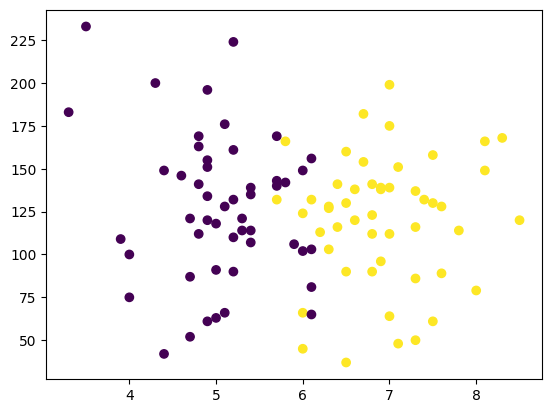

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 3 entries, cgpa to placement
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# **1st Step : extract the input and column**

In [ ]:
X=df.iloc[:,:2]
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
Y=df.iloc[:,-1]
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
x_train,y_train

(    cgpa     iq
 37   8.1  149.0
 16   5.2  224.0
 17   3.3  183.0
 41   5.4  114.0
 55   7.8  114.0
 ..   ...    ...
 20   6.6  120.0
 47   5.2  161.0
 8    6.1  156.0
 82   6.5   37.0
 18   4.0  100.0
 
 [90 rows x 2 columns],
 37    1
 16    0
 17    0
 41    0
 55    1
      ..
 20    1
 47    0
 8     0
 82    1
 18    0
 Name: placement, Length: 90, dtype: int64)

In [ ]:
x_test,x_train

(    cgpa     iq
 75   4.8  169.0
 99   6.2  113.0
 62   6.0  102.0
 87   5.7  132.0
 51   4.8  141.0
 7    5.0   63.0
 27   6.0  124.0
 25   5.0   91.0
 85   5.8  166.0
 44   7.5   61.0,
     cgpa     iq
 37   8.1  149.0
 16   5.2  224.0
 17   3.3  183.0
 41   5.4  114.0
 55   7.8  114.0
 ..   ...    ...
 20   6.6  120.0
 47   5.2  161.0
 8    6.1  156.0
 82   6.5   37.0
 18   4.0  100.0
 
 [90 rows x 2 columns])

# Step 2: Scale the Values (column iq and cgpa have vast diff between the value (we sometimes need to calculate diff btw values for some model so as to not get very diff values we use scaling step))

In [ ]:
from sklearn.preprocessing import StandardScaler

# unscaled data would cause the model to incorrectly treat IQ as more important.
# thats why we are are standardizing the values.

scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)

In [ ]:
np.max(x_train)

np.float64(2.7109028555567787)

In [ ]:
x_test=scaler.fit_transform(x_test)

In [ ]:
np.nanmax(x_test)

np.float64(2.2973645776300713)

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)
y_pred,y_test

(array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1]),
 75    0
 99    1
 62    0
 87    1
 51    0
 7     0
 27    1
 25    0
 85    1
 44    1
 Name: placement, dtype: int64)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

0.8

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

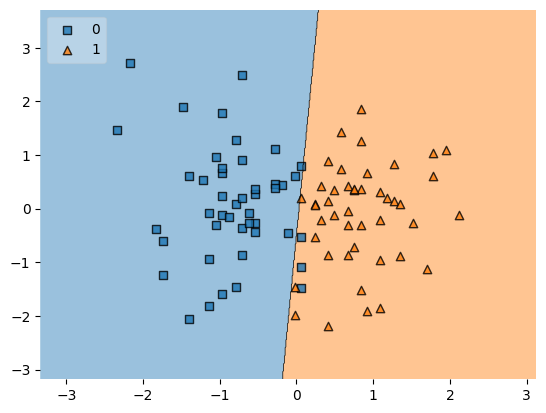

In [ ]:
plot_decision_regions(x_train,y_train.values,clf= model,legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('modelplc.pkl','wb'))